In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

In [3]:
np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1
learning_rate = 0.1
epochs = 10000

# Weight matrices
W1 = np.random.uniform(size=(input_neurons, hidden_neurons))
b1 = np.random.uniform(size=(1, hidden_neurons))

W2 = np.random.uniform(size=(hidden_neurons, output_neurons))
b2 = np.random.uniform(size=(1, output_neurons))


for epoch in range(epochs):

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(final_input)

    error = y - predicted_output
    d_output = error * sigmoid_derivative(predicted_output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate


print("Final Predicted Output after Training:")
print(predicted_output)

Final Predicted Output after Training:
[[0.04690963]
 [0.95663392]
 [0.92548675]
 [0.07177571]]


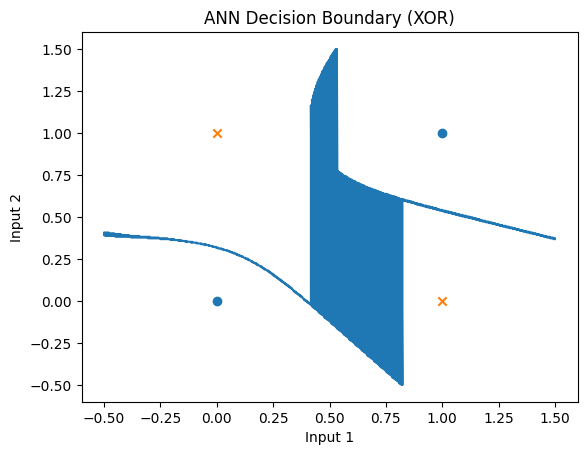

In [11]:
x_values = np.linspace(-0.5, 1.5, 400)
y_values = np.linspace(-0.5, 1.5, 400)

boundary_x = []
boundary_y = []

for x1 in x_values:
    for x2 in y_values:
        point = np.array([[x1, x2]])
        hidden = sigmoid(np.dot(point, W1) + b1)
        output = sigmoid(np.dot(hidden, W2) + b2)

        if abs(output - 0.5) < 0.01:  
            boundary_x.append(x1)
            boundary_y.append(x2)

plt.figure()

plt.scatter(X[y.flatten()==0][:,0], X[y.flatten()==0][:,1], marker='o')
plt.scatter(X[y.flatten()==1][:,0], X[y.flatten()==1][:,1], marker='x')

plt.plot(boundary_x, boundary_y)

plt.title("ANN Decision Boundary (XOR)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()